# Optimizing Coronagraph Masks
In this how-to, we will show you how to use `dygdug` for Apodized Pupil Lyot Coronagraph (APLCs) optimization. This tutorial will follow the Optimizing Coronagraphs how-to, so consider checking that out to set up a simple coronagraph optimization in `dygdug`.

The difficulty with APLCs is that to be manufacturable, they need to achieve high contrast while using binary solutions. This is simple in principle, but difficult to implement for optimizers which operate on a generally smooth and unbounded solution space. One area where we can help this out is by using `x.optym`'s box constraints, which restrict the domain of the solution to $[0,1]$.

First, let's set up the optimization with a `mode="amplitude"` `VariablePupil` object.

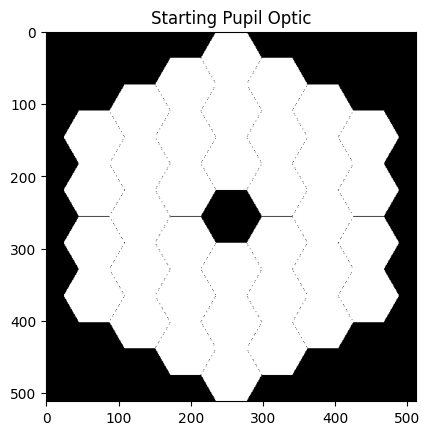

In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from prysm.propagation import prepare_executor 
from prysm.segmented import VERTEX_TO_VERTEX_TO_FLAT_TO_FLAT
from prysm.mathops import set_backend_to_cupy, np

from dygdug.masks import Pupil, FPM
from dygdug.coropt import VariablePupil
from dygdug.models import Coronagraph



# Define instrument parameters
circumscribed_diameter = 10.95e3
Npup = 512
Nfoc = 128
wvl = 1 
fno = 13.66
efl = fno * circumscribed_diameter 
lamD = wvl / circumscribed_diameter * efl
px_per_lamD = 4 # the "oversampling"
seg_diam = VERTEX_TO_VERTEX_TO_FLAT_TO_FLAT * 1800


# Define VARIABLE entrance pupil
pupil = VariablePupil.hexagonal_segmented(
    Dpup=circumscribed_diameter, 
    Npup=Npup,
    rings=3,                 
    segment_diameter=seg_diam, 
    segment_separation=5, 
    exclude=(0,),
    mode="amplitude" # special argument for VariablePupil
)

plt.figure()
plt.title("Starting Pupil Optic")
plt.imshow(pupil.data, cmap="gray")
plt.show()


Next, we just define the remaining optics and `Coronagraph` object that puts it all together

In [2]:
# ensure we are using the GPU backend
# set_backend_to_cupy()

# update the VariablePupil data to be a cupy array
pupil.data = np.asarray(pupil.data)

# Define a prysm executor the controls the propagation
executor = prepare_executor(
    pupil_dx=circumscribed_diameter / Npup,
    pupil_samples=Npup,
    focal_dx=lamD / px_per_lamD,
    focal_samples=Nfoc,
    wavelength=wvl,
    efl=efl,
    focal_shift=(0, 0),
    kind="mdft",
)

# Define focal plane mask
fpm = FPM.annular(
    N=Nfoc,
    lamD=lamD,
    px_per_lamD=px_per_lamD,
    inner_radius=3,
    outer_radius=12,
)

# Define the lyot stop
lyot = Pupil.annular(
    Dpup=circumscribed_diameter,
    Npup=Npup,
    inner_radius=0.2 * circumscribed_diameter / 2,
    outer_radius=0.8 * circumscribed_diameter / 2
)

coro = Coronagraph(pupil=pupil, fpm=fpm, lyot_stop=lyot, executor=executor)

Next, we define the coronagraph optimizer

In [7]:
from dygdug.coropt import CoronagraphOptimizer
from dygdug.cost_functions import FieldMeanSquaredError
from dygdug.masks import annular_mask, ImgSamplingSpec, knife_edge_mask

# Define Image Plane Sampling Specification and Dark Hole
iss = ImgSamplingSpec.from_N_lamD_px_per_lamD(Nfoc, lamD, px_per_lamD)
dark_hole = annular_mask(iss, iwa=3, owa=12, theta_min=-90, theta_max=90)
dark_hole *= knife_edge_mask(iss, iwa=3)


# Define cost function
target_contrast = 1e-10
target_field = np.sqrt(target_contrast)
cost_function = FieldMeanSquaredError(target=target_field)

# Define the starting parameter vector
x0 = np.ones_like(pupil.data[pupil.mask], dtype="float64")

# Define the CoronagraphOptimizer
coroopt = CoronagraphOptimizer(
    dark_hole=dark_hole,
    coro=coro,
    wvl=[wvl], # just perform monochromatic for now
    cost=cost_function
)


Next, we use `prysm`'s available optimization routines to conduct the optimization. The difference here is that we will define upper and lower bounds that the solution space will be restricted to.

100%|██████████| 1000/1000 [00:30<00:00, 32.41it/s]


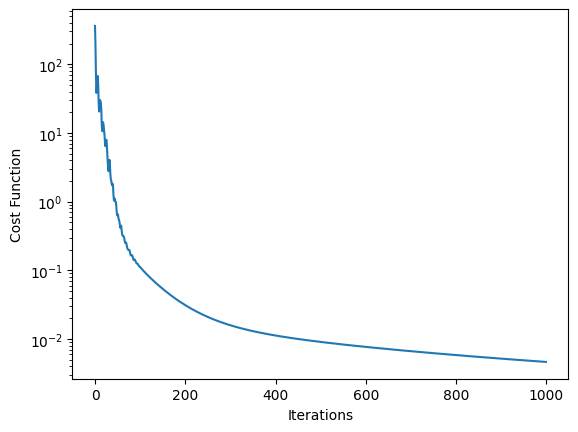

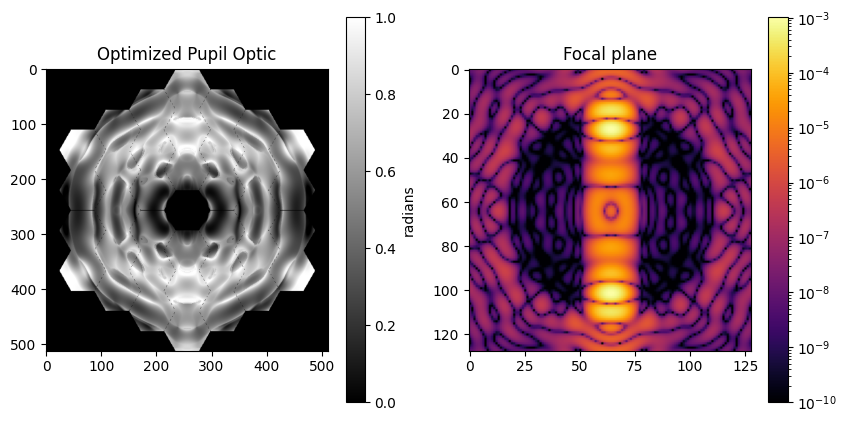

In [8]:
from tqdm import tqdm
from prysm.x.optym import Yogi, PrysmLBFGSB

upper_bounds = np.ones_like(x0)
lower_bounds = np.zeros_like(x0)

opt = Yogi(fg=coroopt.fg, x0=x0, alpha=0.5, upper_bounds=upper_bounds, lower_bounds=lower_bounds)
cost = []
N_ITER = 1000
for i in tqdm(range(N_ITER)):
    opt.step()
    cost.append(coroopt.J)

xf = opt.x.copy()
pupil.update(xf)
field = coro.forward(wvl=wvl, include_fpm=True)
ref_field = coro.forward(wvl=wvl, include_fpm=False)

intensity = np.abs(field) ** 2
ref_intensity = np.abs(ref_field) ** 2
contrast_norm = ref_intensity.max()
intensity /= contrast_norm

plt.figure()
plt.plot(cost)
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")


plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title("Optimized Pupil Optic")
plt.imshow(pupil.data, cmap="gray")
plt.colorbar(label="radians")
plt.subplot(122)
plt.title("Focal plane")
plt.imshow(intensity, cmap="inferno", norm=LogNorm(vmin=1e-10))
plt.colorbar()
plt.show()

Now, technically this gets us near the constrast we asked for - but at the cost of our mask throughput. This is because we are using throughput as the apodization pattern for creating a high-contrast zone. This means we need to jointly optimize throughput and contrast, with the understanding that these two parameters might fight eachother. We perform this kind of joint optimization in `dygdug` via the `JointOptimizer` class.

In [ ]:
from dygdug.coropt import JointOptimizer, ThroughputOptimizer

# We grid-searched for this before writing the demo, don't worry about it for now
lagrange_mult = 8e-5

throughput_opt = ThroughputOptimizer(coro, alpha=lagrange_mult)

joint_opt = JointOptimizer([
    coroopt,
    throughput_opt
])

The `JointOptimizer` is just an object that sums the function and gradient values of the constituent optimizers, so if you wanted, you could easilly implement it yourself. Let's run the optimization and see what happens.

100%|██████████| 1000/1000 [00:31<00:00, 31.50it/s]


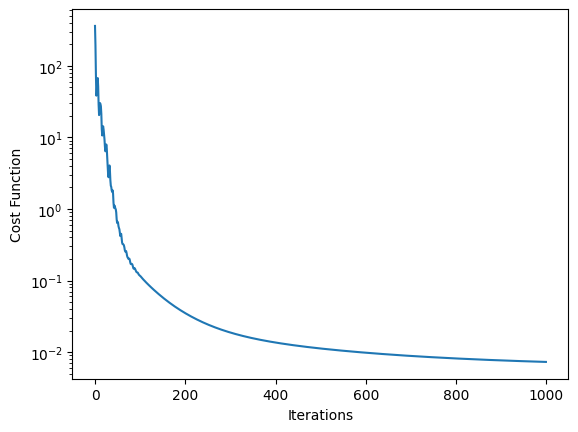

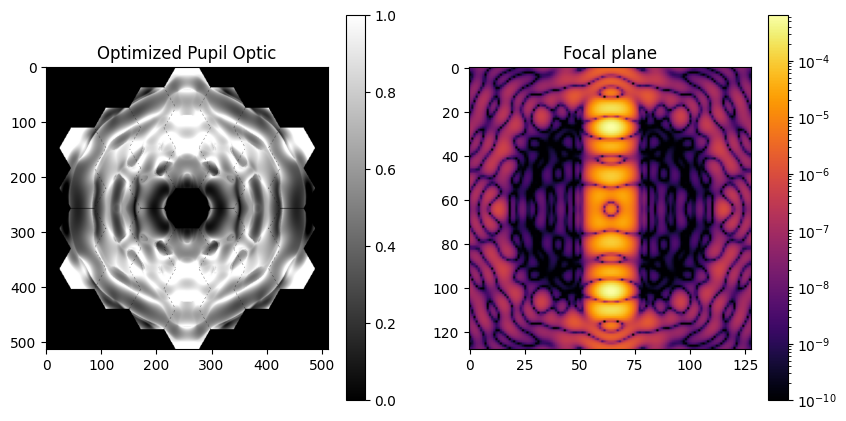

In [ ]:
opt = Yogi(fg=joint_opt.fg, x0=x0, alpha=0.5, upper_bounds=upper_bounds, lower_bounds=lower_bounds)
cost = []
N_ITER = 10_000
for i in tqdm(range(N_ITER)):
    opt.step()
    cost.append(coroopt.J)

xf = opt.x.copy()
pupil.update(xf)
field = coro.forward(wvl=wvl, include_fpm=True)
ref_field = coro.forward(wvl=wvl, include_fpm=False)

intensity = np.abs(field) ** 2
ref_intensity = np.abs(ref_field) ** 2
contrast_norm = ref_intensity.max()
intensity /= contrast_norm

plt.figure()
plt.plot(cost)
plt.xlabel("Iterations")
plt.ylabel("Cost Function")
plt.yscale("log")

plt.figure(figsize=[10, 5])
plt.subplot(121)
plt.title("Optimized Pupil Optic")
plt.imshow(pupil.data, cmap="gray")
plt.colorbar()
plt.subplot(122)
plt.title("Focal plane")
plt.imshow(intensity, cmap="inferno", norm=LogNorm(vmin=1e-10))
plt.colorbar()
plt.show()


What we get is a binary, relatively high-throughput APLC with a symmetric dark zone. This is a consequence of the hermetian symmetry of amplitude apodizers, and something you get for free for APLCs. Note that the cost function landscape is very different from our single-cost prior examples. The initial dip is because of the throughput maximization at the cost of high contrast. The slow return is the solutions attempt to maintain high throughput _and_ contrast. An important aspect of this demonstration that we are leaving out is the lagrange multiplier, or "optimization weight" placed on the throughput optimizer. This is critical for convergence, and determines the right "balance" of throughput and contrast to get a desireable design.

The process of solving for the right lagrange multipliers is worth its own tutorial (or two), and so will not be covered here. However, with the speed of `prysm` we are able to grid-search for lagrange multipliers somewhat easily!